In [13]:
import pandas as pd
import json
from pandas import json_normalize
import os

In [14]:
with open('categorized_tasks-gpt-4o-tool-calling-gpt-4o-0.0_range_0--1_user-gpt-4o-telecom.json', 'r') as f:
    data = json.load(f)
df = json_normalize(
    data,
    record_path=["conversations"],
    meta=["Task id"],  # bring parent key along
)
df.head()

,intent,conversation_segment,category,reasoning,Task id
0,GET_ACCOUNT_DETAILS,"User: Hi, I'm Sarah Johnson. Could you please ...",procedural,The conversation is procedural because the use...,0
1,HANDLE_BILLING_PAYMENTS,"User: Great, thank you! Could you also help me...",declarative,The conversation is declarative because the us...,0
2,SUPPORT_TICKET,"User: Wait a minute, I'm only supposed to be p...",procedural,The conversation is procedural because the use...,0
3,GET_ACCOUNT_DETAILS,User: Hi there! I'd like to start by seeing al...,procedural,The conversation is procedural because the use...,1
4,TROUBLESHOOT,User: Thanks for sharing that. I have a confer...,procedural,The conversation is procedural because the use...,1


In [15]:
df[["Task id", "intent","conversation_segment","reasoning","category"]].to_csv("csv's/categorized_tasks-gpt-4o-gpt-4o-telecom.csv", index=False)


In [16]:
df_counts = df.groupby(["Task id", "category"]) \
.size()  \
.unstack(fill_value=0)  \
.reset_index()
df_counts

category,Task id,declarative,procedural
0,0,1,2
1,1,1,2


In [17]:
df_counts["sub_tasks"] = df_counts["procedural"] + df_counts["declarative"]
df_counts["procedural_ratio"] =  df_counts["procedural"] / df_counts["sub_tasks"]
df_counts["declarative_ratio"] =  df_counts["declarative"] / df_counts["sub_tasks"]
df_counts.to_csv("csv's/task_category_counts_ratio-gpt-4o-gpt-4o-telecom.csv", index=False)

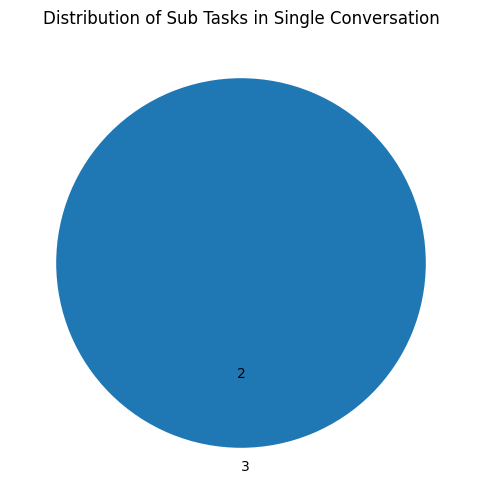

In [18]:
import matplotlib.pyplot as plt

# Count occurrences of each unique value
subtask_counts = df_counts["sub_tasks"].value_counts()

# Custom function to show counts
def absolute_value(pct, all_vals):
    total = sum(all_vals)
    count = int(round(pct * total / 100.0))
    return f"{count}"

# Create pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    subtask_counts,
    labels=subtask_counts.index,
    autopct=lambda pct: absolute_value(pct, subtask_counts),
    startangle=90
)
plt.title("Distribution of Sub Tasks in Single Conversation")
plt.show()

In [19]:
df_tasks_counts = df.groupby(["intent", "category"]) \
.size()  \
.unstack(fill_value=0)  \
.reset_index()
df_tasks_counts

category,intent,declarative,procedural
0,GET_ACCOUNT_DETAILS,0,2
1,HANDLE_BILLING_PAYMENTS,1,0
2,MANAGE_MY_SERVICES,1,0
3,SUPPORT_TICKET,0,1
4,TROUBLESHOOT,0,1


In [20]:
df_tasks_counts.to_csv("csv's/task_category_counts-gpt-4o-gpt-4o-telecom.csv", index=False)

In [21]:
grouped = df.groupby(["intent", "category"])
_df_tasks_counts = grouped.size().reset_index(name="count")
df_taskids = grouped["Task id"].apply(list).reset_index(name="task_ids")
df_tasks_counts_withids = _df_tasks_counts.merge(df_taskids, on=["intent", "category"], how="left")
df_tasks_counts_withids

,intent,category,count,task_ids
0,GET_ACCOUNT_DETAILS,procedural,2,"[0, 1]"
1,HANDLE_BILLING_PAYMENTS,declarative,1,[0]
2,MANAGE_MY_SERVICES,declarative,1,[1]
3,SUPPORT_TICKET,procedural,1,[0]
4,TROUBLESHOOT,procedural,1,[1]


In [22]:
df_tasks_counts_withids.to_csv("csv's/task_category_counts_withids-gpt-4o-gpt-4o-telecom.csv", index=False)

In [23]:
df_counts["procedural_flag"] = df_counts["procedural"].apply(lambda x: "yes" if x > 0 else "no")
df_counts["declarative_flag"] = df_counts["declarative"].apply(lambda x: "yes" if x > 0 else "no")
df_counts["sub_tasks"] = df_counts["procedural"] + df_counts["declarative"]

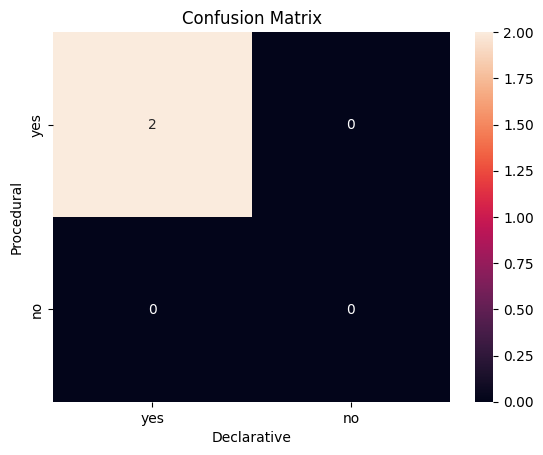

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(df_counts['procedural_flag'], df_counts['declarative_flag'], labels=['yes', 'no'])

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['yes', 'no'], yticklabels=['yes', 'no'])
plt.xlabel('Declarative')
plt.ylabel('Procedural')
plt.title('Confusion Matrix')
plt.show()